In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/student_data.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/student_data.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\adeor\Documents\student-performance-prediction


In [4]:
print(os.listdir())

['.ipynb_checkpoints', 'create_dataset.py', 'data', 'models', 'notebooks', 'src', 'student-performance-prediction.ipynb', 'venv', 'visualizations']


In [5]:
import pandas as pd

df = pd.read_csv("data/student_data.csv")

df.head()

,study_hours,attendance_percent,previous_score,sleep_hours,assignment_score,extracurricular_hours,internet_access,parental_education,final_score,performance_category
0,6.49,94.8,58.5,4.7,59.0,2.2,Yes,Graduate,76.7,High
1,5.22,89.1,66.0,6.0,71.5,2.1,Yes,Postgraduate,70.2,Medium
2,6.80,78.7,56.9,6.5,72.3,0.0,Yes,Diploma,64.5,Medium
3,8.55,70.2,63.7,9.3,79.1,2.3,Yes,Postgraduate,85.2,High
4,5.03,86.4,41.5,7.7,51.5,4.5,No,Postgraduate,67.9,Medium


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 10


In [7]:
df.columns

Index(['study_hours', 'attendance_percent', 'previous_score', 'sleep_hours',
       'assignment_score', 'extracurricular_hours', 'internet_access',
       'parental_education', 'final_score', 'performance_category'],
      dtype='str')

In [8]:
df.isnull().sum()

study_hours              0
attendance_percent       0
previous_score           0
sleep_hours              0
assignment_score         0
extracurricular_hours    0
internet_access          0
parental_education       0
final_score              0
performance_category     0
dtype: int64

In [9]:
df.describe()

,study_hours,attendance_percent,previous_score,sleep_hours,assignment_score,extracurricular_hours,final_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,5.531140,78.672000,68.014300,6.976500,71.126600,2.970700,73.05050
std,1.924603,11.588851,13.527718,1.223534,14.575313,1.896013,9.19657
min,0.500000,42.700000,30.000000,4.000000,24.300000,0.000000,44.10000
25%,4.207500,70.700000,58.900000,6.100000,61.775000,1.600000,66.80000
50%,5.550000,78.750000,68.000000,7.000000,71.750000,2.900000,72.70000
75%,6.800000,86.725000,77.225000,7.800000,81.625000,4.200000,79.12500
max,10.000000,100.000000,100.000000,10.000000,100.000000,9.200000,100.00000


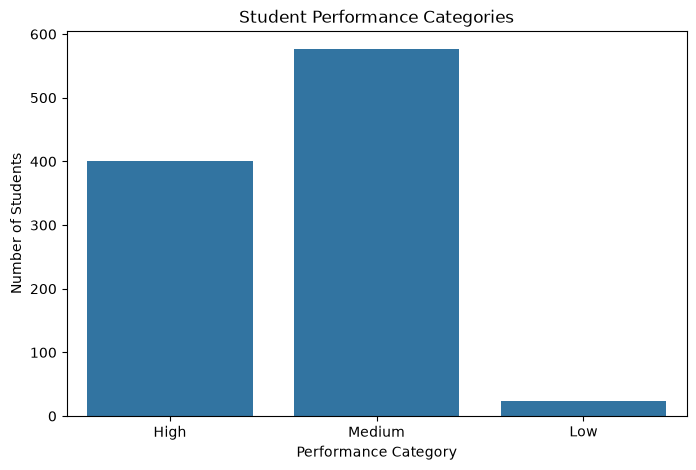

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="performance_category"
)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

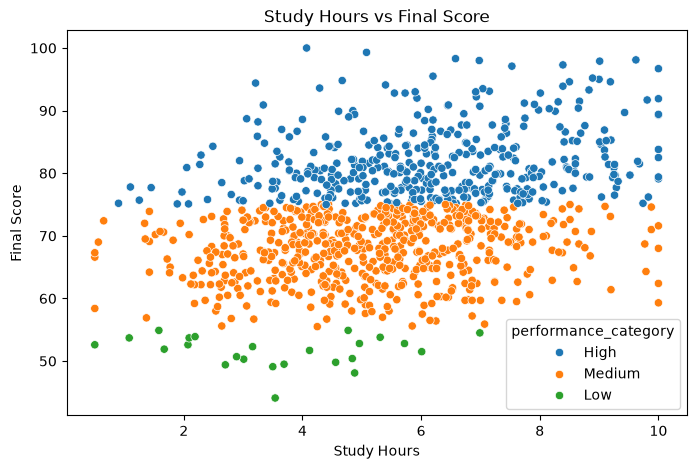

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="study_hours",
    y="final_score",
    hue="performance_category"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

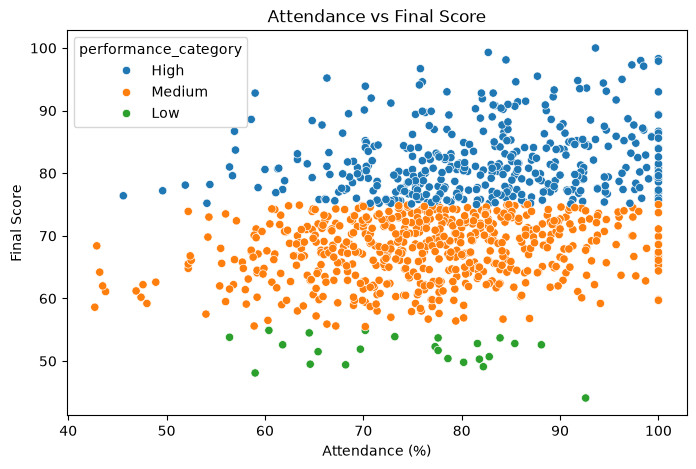

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_percent",
    y="final_score",
    hue="performance_category"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()

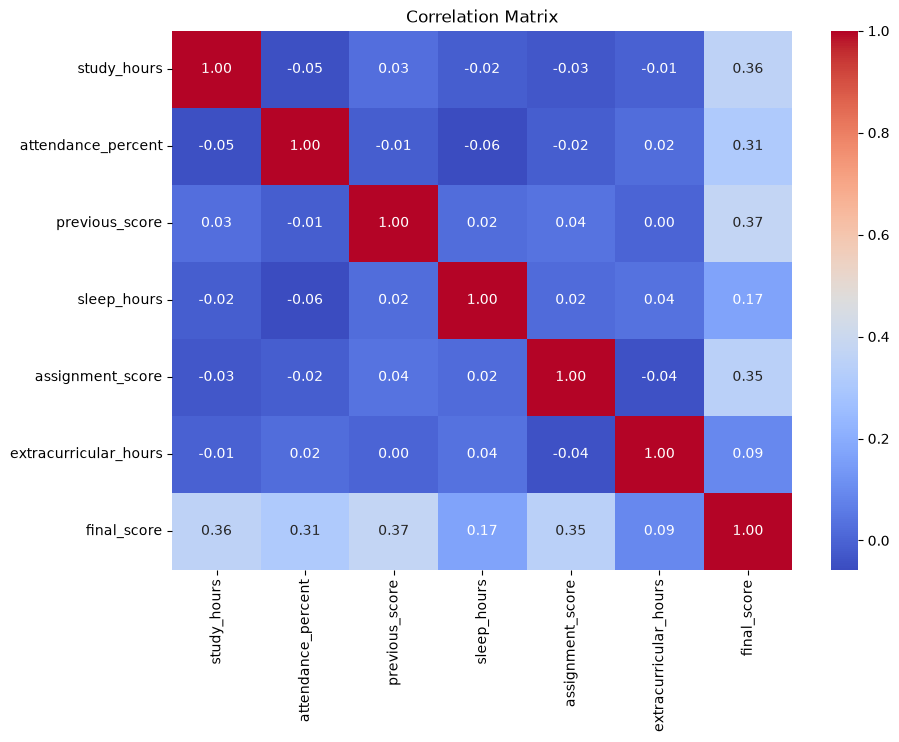

In [13]:
numeric_columns = [
    "study_hours",
    "attendance_percent",
    "previous_score",
    "sleep_hours",
    "assignment_score",
    "extracurricular_hours",
    "final_score"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataset
ml_data = df.copy()

# Convert categorical columns into numbers
label_encoder = LabelEncoder()

ml_data["internet_access"] = label_encoder.fit_transform(
    ml_data["internet_access"]
)

ml_data["parental_education"] = label_encoder.fit_transform(
    ml_data["parental_education"]
)

# Separate features (X) and target (y)
X = ml_data.drop(
    columns=["final_score", "performance_category"]
)

y = ml_data["performance_category"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [15]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


C:\Users\adeor\Documents\student-performance-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Predict performance for the test data
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predictions:")
print(y_pred_logistic[:10])

Predictions completed successfully!
First 10 predictions:
['Medium' 'High' 'High' 'High' 'Medium' 'High' 'High' 'High' 'Medium'
 'Medium']


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:")
print(f"{accuracy_logistic * 100:.2f}%")

# Detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy:
77.50%

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.78      0.76        80
         Low       0.00      0.00      0.00         5
      Medium       0.80      0.81      0.81       115

    accuracy                           0.78       200
   macro avg       0.51      0.53      0.52       200
weighted avg       0.76      0.78      0.77       200


Confusion Matrix:
[[62  0 18]
 [ 0  0  5]
 [22  0 93]]


C:\Users\adeor\Documents\student-performance-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adeor\Documents\student-performance-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\adeor\Documents\student-performance-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [19]:
# Predict performance using Decision Tree
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree predictions completed successfully!")
print("First 10 predictions:")
print(y_pred_tree[:10])

Decision Tree predictions completed successfully!
First 10 predictions:
['High' 'High' 'High' 'Medium' 'Medium' 'High' 'High' 'High' 'Medium'
 'Medium']


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:")
print(f"{accuracy_tree * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy:
64.50%

Classification Report:
              precision    recall  f1-score   support

        High       0.57      0.72      0.64        80
         Low       0.00      0.00      0.00         5
      Medium       0.72      0.62      0.67       115

    accuracy                           0.65       200
   macro avg       0.43      0.45      0.44       200
weighted avg       0.65      0.65      0.64       200


Confusion Matrix:
[[58  0 22]
 [ 0  0  5]
 [43  1 71]]


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Predict performance using Random Forest
y_pred_forest = random_forest_model.predict(X_test)

print("Random Forest predictions completed successfully!")
print("First 10 predictions:")
print(y_pred_forest[:10])

Random Forest predictions completed successfully!
First 10 predictions:
['Medium' 'High' 'High' 'Medium' 'Medium' 'High' 'High' 'High' 'Medium'
 'Medium']


In [23]:
# Calculate Random Forest accuracy
accuracy_forest = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:")
print(f"{accuracy_forest * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_forest,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_forest
))

Random Forest Accuracy:
74.50%

Classification Report:
              precision    recall  f1-score   support

        High       0.72      0.70      0.71        80
         Low       0.00      0.00      0.00         5
      Medium       0.76      0.81      0.78       115

    accuracy                           0.74       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.73      0.74      0.73       200


Confusion Matrix:
[[56  0 24]
 [ 0  0  5]
 [22  0 93]]


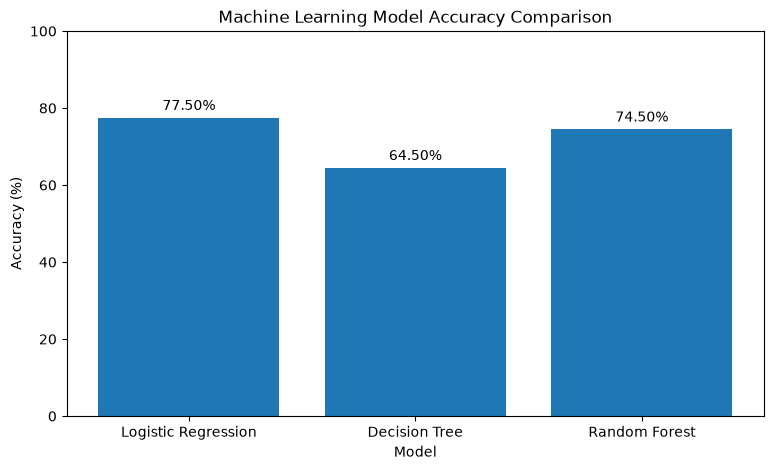

In [24]:
# Model accuracy comparison

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

model_accuracies = [
    accuracy_logistic * 100,
    accuracy_tree * 100,
    accuracy_forest * 100
]

plt.figure(figsize=(9, 5))

plt.bar(model_names, model_accuracies)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Display accuracy values above each bar
for i, accuracy in enumerate(model_accuracies):
    plt.text(
        i,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

In [25]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Importance
0            study_hours    0.213417
2         previous_score    0.199321
1     attendance_percent    0.184657
4       assignment_score    0.160443
3            sleep_hours    0.102542
5  extracurricular_hours    0.090858
7     parental_education    0.039943
6        internet_access    0.008819


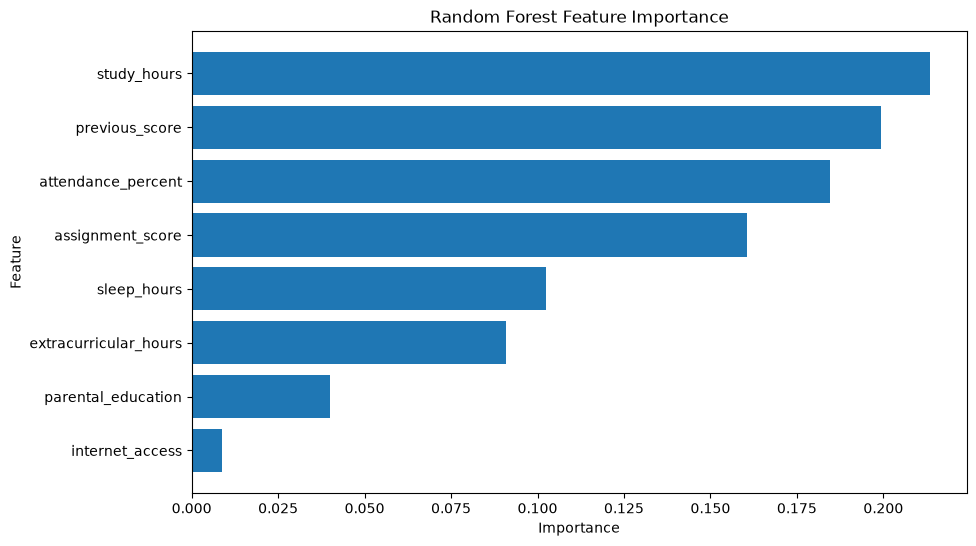

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.savefig(
    "visualizations/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
import joblib

joblib.dump(
    logistic_model,
    "models/logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [28]:
import joblib

# Load the saved model
loaded_model = joblib.load(
    "models/logistic_regression_model.pkl"
)

print("Saved model loaded successfully!")

# Make predictions using the loaded model
test_predictions = loaded_model.predict(X_test)

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Saved model loaded successfully!

First 10 predictions:
['Medium' 'High' 'High' 'High' 'Medium' 'High' 'High' 'High' 'Medium'
 'Medium']


In [29]:
loaded_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Loaded Model Accuracy: {loaded_accuracy * 100:.2f}%")

Loaded Model Accuracy: 77.50%


In [30]:
# Student Performance Prediction

study_hours = float(input("Enter study hours per day: "))
attendance_percent = float(input("Enter attendance percentage: "))
previous_score = float(input("Enter previous score: "))
sleep_hours = float(input("Enter average sleep hours: "))
assignment_score = float(input("Enter assignment score: "))
extracurricular_hours = float(input("Enter extracurricular hours per day: "))

internet_access = input("Internet access (Yes/No): ")
parental_education = input("Parental education (School/Graduate/Postgraduate): ")

# Convert categorical values to the same format used during training
internet_mapping = {
    "No": 0,
    "Yes": 1
}

parental_mapping = {
    "Graduate": 0,
    "Postgraduate": 1,
    "School": 2
}

internet_access_encoded = internet_mapping[internet_access]
parental_education_encoded = parental_mapping[parentental_education]

Enter study hours per day:  4
Enter attendance percentage:  85
Enter previous score:  75
Enter average sleep hours:  7
Enter assignment score:  80
Enter extracurricular hours per day:  2
Internet access (Yes/No):  yes
Parental education (School/Graduate/Postgraduate):  graduate


KeyError: 'yes'

In [33]:
print("Internet access categories:")
print(df["internet_access"].unique())

print("\nParental education categories:")
print(df["parental_education"].unique())

Internet access categories:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Parental education categories:
<StringArray>
['Graduate', 'Postgraduate', 'Diploma', 'High School']
Length: 4, dtype: str


In [34]:
from sklearn.preprocessing import LabelEncoder

# Recreate the exact encoders used for training
internet_encoder = LabelEncoder()
parental_encoder = LabelEncoder()

internet_encoder.fit(df["internet_access"])
parental_encoder.fit(df["parental_education"])

print("Internet access mapping:")
for value, number in zip(
    internet_encoder.classes_,
    internet_encoder.transform(internet_encoder.classes_)
):
    print(value, "=", number)

print("\nParental education mapping:")
for value, number in zip(
    parental_encoder.classes_,
    parental_encoder.transform(parental_encoder.classes_)
):
    print(value, "=", number)

Internet access mapping:
No = 0
Yes = 1

Parental education mapping:
Diploma = 0
Graduate = 1
High School = 2
Postgraduate = 3


In [36]:
# Student Performance Prediction

study_hours = float(input("Enter study hours per day: "))
attendance_percent = float(input("Enter attendance percentage: "))
previous_score = float(input("Enter previous score: "))
sleep_hours = float(input("Enter average sleep hours: "))
assignment_score = float(input("Enter assignment score: "))
extracurricular_hours = float(
    input("Enter extracurricular hours per day: ")
)

internet_access = input("Internet access (Yes/No): ").strip().title()

parental_education = input(
    "Parental education (Diploma/Graduate/High School/Postgraduate): "
).strip().title()

# Encode categorical values
internet_access_encoded = internet_encoder.transform(
    [internet_access]
)[0]

parental_education_encoded = parental_encoder.transform(
    [parental_education]
)[0]

# Create student input
student_data = [[
    study_hours,
    attendance_percent,
    previous_score,
    sleep_hours,
    assignment_score,
    extracurricular_hours,
    internet_access_encoded,
    parental_education_encoded
]]

# Make prediction
prediction = loaded_model.predict(student_data)

print("\nPredicted Performance:", prediction[0])

Enter study hours per day:  4
Enter attendance percentage:  85
Enter previous score:  75
Enter average sleep hours:  7
Enter assignment score:  80
Enter extracurricular hours per day:  2
Internet access (Yes/No):  yes
Parental education (Diploma/Graduate/High School/Postgraduate):  graduate



Predicted Performance: High


C:\Users\adeor\Documents\student-performance-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
